To analyze and visualize output

In [3]:
import pandas as pd, numpy as np
from itertools import combinations
from scipy.stats import spearmanr

# === Load your files ===
dms = pd.read_csv("../data/dms_le2.csv")[["sequence","fitness"]].rename(columns={"sequence":"seq"})
seed96 = pd.read_csv("../results/STEP2_initial96.csv")[["sequence","fitness"]].rename(columns={"sequence":"seq"})
props1 = pd.read_csv("../results/STEP5_bo_proposals_round1.csv")[["seq","mu","sigma","ei","hd_to_WT"]]
props2 = pd.read_csv("../results/STEP5_bo_proposals_round2.csv")[["seq","mu","sigma","ei","hd_to_WT"]]

truth = dict(zip(dms["seq"], dms["fitness"]))

# === helpers ===
def y_of(seqs): return np.array([truth.get(s,np.nan) for s in seqs],dtype=float)
def hamming(a,b): return sum(c1!=c2 for c1,c2 in zip(a,b))
def mean_pairwise_hamming(seqs):
    if len(seqs)<2: return 0
    return np.mean([hamming(x,y) for x,y in combinations(seqs,2)])
def topk_true_in_selected(selected,pool,k):
    pool_sorted = sorted(pool,key=lambda s: truth.get(s,-np.inf),reverse=True)
    true_top = set(pool_sorted[:min(k,len(pool_sorted))])
    sel = set(selected)
    hit = len(sel & true_top)
    return hit/min(k,len(sel))

# === reconstruct round pools ===
measured_r0 = set(seed96["seq"])
pool_r1 = [s for s in dms["seq"] if s not in measured_r0]
sel_r1 = props1["seq"].tolist()
measured_r1 = measured_r0 | set(sel_r1)
pool_r2 = [s for s in dms["seq"] if s not in measured_r1]
sel_r2 = props2["seq"].tolist()

# === metrics ===
def round_metrics(round_id, selected, pool, measured_prev, props_df):
    y_sel = y_of(selected)
    best_prev = np.nanmax(y_of(list(measured_prev))) if measured_prev else np.nan
    best_now = np.nanmax(y_of(list(measured_prev | set(selected))))
    avg_sel = np.nanmean(y_sel)
    gain_best = best_now - best_prev
    gain_avg  = avg_sel - best_prev
    div = mean_pairwise_hamming(selected)
    hit24 = topk_true_in_selected(selected,pool,24)
    hit96 = topk_true_in_selected(selected,pool,96)
    rho = np.nan
    if "mu" in props_df.columns:
        mask = ~np.isnan(y_sel)
        rho = spearmanr(props_df.loc[mask,"mu"], y_sel[mask]).correlation
    return {
        "round":round_id,
        "best_so_far":best_now,
        "avg_selected":avg_sel,
        "gain_best_vs_prev":gain_best,
        "gain_avg_vs_prevbest":gain_avg,
        "diversity_mean_hamming":div,
        "Hit@24":hit24,
        "Hit@96":hit96,
        "Spearman(μ,true)":rho
    }

summary = []
summary.append(round_metrics(1, sel_r1, pool_r1, measured_r0, props1))
summary.append(round_metrics(2, sel_r2, pool_r2, measured_r1, props2))
summary_df = pd.DataFrame(summary)
summary_df


,round,best_so_far,avg_selected,gain_best_vs_prev,gain_avg_vs_prevbest,diversity_mean_hamming,Hit@24,Hit@96,"Spearman(μ,true)"
0,1,3.96327,3.540191,0.0,-0.423079,3.500000,0.0,0.0,0.234783
1,2,3.96327,3.619034,0.0,-0.344236,2.163043,0.0,0.0,0.053913


In [14]:
print(dms['fitness'].mean())
print(dms['fitness'].max())
print(dms['fitness'].mode())

3.3523272598737353
4.11357579525
0    1.301030
1    1.301030
2    3.259355
3    3.693903
4    3.775974
Name: fitness, dtype: float64


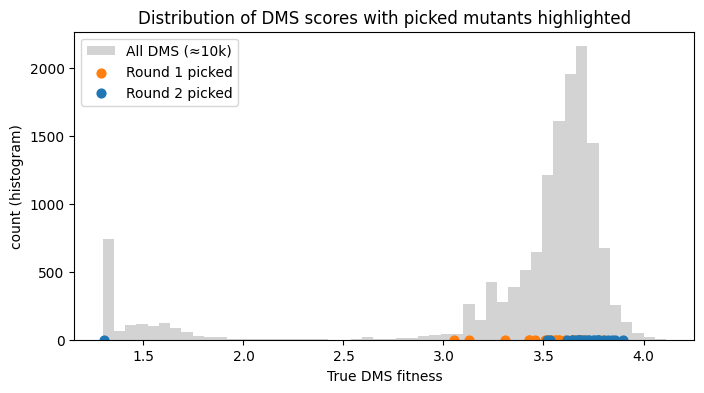

In [5]:
import matplotlib.pyplot as plt

# all DMS scores
pool_scores = dms["fitness"].values

# highlight the 24 chosen in this round
sel1_scores = y_of(sel_r1)
sel2_scores = y_of(sel_r2)

plt.figure(figsize=(8,4))
plt.hist(pool_scores, bins=50, color="lightgray", label="All DMS (≈10k)")
plt.scatter(sel1_scores, np.zeros_like(sel1_scores), color="tab:orange", s=40, label="Round 1 picked")
plt.scatter(sel2_scores, np.zeros_like(sel2_scores)-0.002, color="tab:blue", s=40, label="Round 2 picked")
plt.xlabel("True DMS fitness")
plt.ylabel("count (histogram)")
plt.title("Distribution of DMS scores with picked mutants highlighted")
plt.legend()
plt.show()



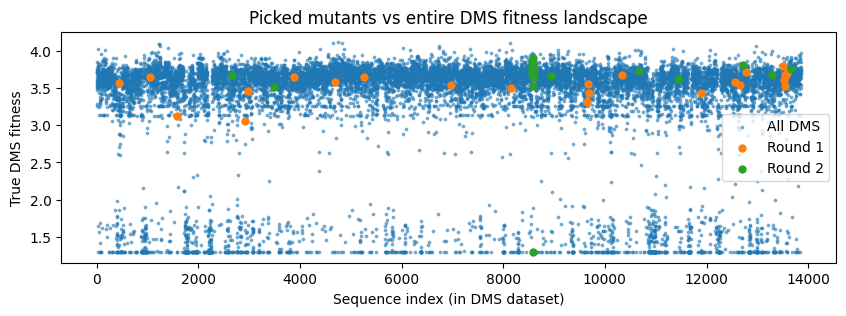

In [9]:
plt.figure(figsize=(10,3))
plt.scatter(range(len(dms)), dms["fitness"], s=3, alpha=0.5, label="All DMS")
sel_idx1 = dms.index[dms["seq"].isin(sel_r1)]
sel_idx2 = dms.index[dms["seq"].isin(sel_r2)]
plt.scatter(sel_idx1, dms.loc[sel_idx1,"fitness"], color="tab:orange", s=25, label="Round 1")
plt.scatter(sel_idx2, dms.loc[sel_idx2,"fitness"], color="tab:green", s=25, label="Round 2")
plt.ylabel("True DMS fitness")
plt.xlabel("Sequence index (in DMS dataset)")
plt.title("Picked mutants vs entire DMS fitness landscape")
plt.legend()
plt.show()


Text(0.5, 1.0, 'Learning curve (GFP DMS simulation)')

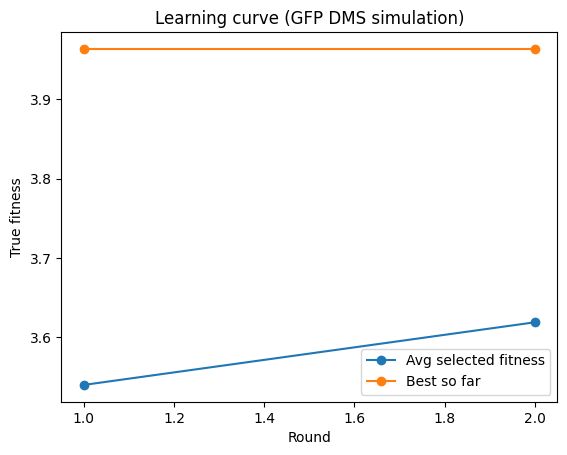

In [15]:
plt.figure()
plt.plot(summary_df["round"], summary_df["avg_selected"], marker="o", label="Avg selected fitness")
plt.plot(summary_df["round"], summary_df["best_so_far"], marker="o", label="Best so far")
plt.legend(); plt.xlabel("Round"); plt.ylabel("True fitness")
plt.title("Learning curve (GFP DMS simulation)")
